Dataset loaded. Shape: (100000, 7)
   TransactionID             TransactionDate   Amount  MerchantID  \
0              1  2024-04-03 14:15:35.462794  4189.27         688   
1              2  2024-03-19 13:20:35.462824  2659.71         109   
2              3  2024-01-08 10:08:35.462834   784.00         394   
3              4  2024-04-13 23:50:35.462850  3514.40         944   
4              5  2024-07-12 18:51:35.462858   369.07         475   

  TransactionType      Location  IsFraud  
0          refund   San Antonio        0  
1          refund        Dallas        0  
2        purchase      New York        0  
3        purchase  Philadelphia        0  
4        purchase       Phoenix        0  
After SMOTE: (158400, 1014) IsFraud
0    79200
1    79200
Name: count, dtype: int64

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.00      0.00      0.00       200

    ac

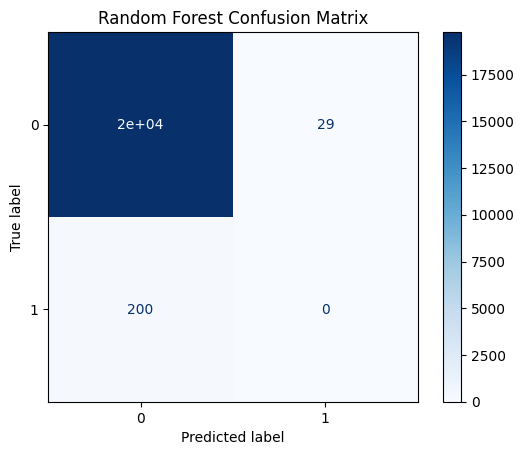

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:29:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.00      0.00      0.00       200

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000



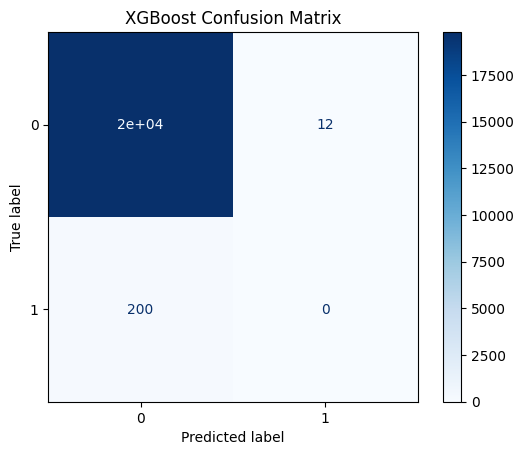


Isolation Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19800
           1       0.01      0.01      0.01       200

    accuracy                           0.98     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.98      0.98     20000



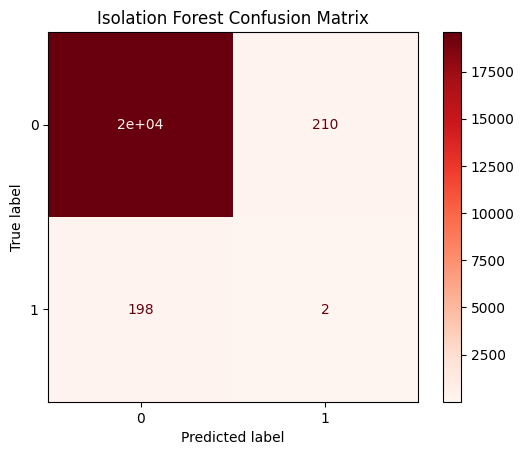

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
file_path = "/content/credit_card_fraud_dataset.csv"
df = pd.read_csv(file_path)
print("Dataset loaded. Shape:", df.shape)
print(df.head())
if 'TransactionID' in df.columns:
    df.drop(columns=['TransactionID'], inplace=True)
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    df['Year'] = df['TransactionDate'].dt.year
    df['Month'] = df['TransactionDate'].dt.month
    df['Day'] = df['TransactionDate'].dt.day
    df['Hour'] = df['TransactionDate'].dt.hour
    df.drop(columns=['TransactionDate'], inplace=True)
target = 'IsFraud'
X = df.drop(columns=[target])
y = df[target]
num_features = ['Amount', 'Year', 'Month', 'Day', 'Hour']
cat_features = ['MerchantID', 'TransactionType', 'Location']
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
scaler = StandardScaler()
X_train_encoded[num_features] = scaler.fit_transform(X_train_encoded[num_features])
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_encoded, y_train)
print("After SMOTE:", X_train_bal.shape, y_train_bal.value_counts())
X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded[num_features] = scaler.transform(X_test_encoded[num_features])
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_encoded)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.show()
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(X_train_encoded)
anomaly_pred = iso_forest.predict(X_test_encoded)
anomaly_pred = np.where(anomaly_pred == -1, 1, 0)
print("\nIsolation Forest Classification Report:")
print(classification_report(y_test, anomaly_pred))
cm_iso = confusion_matrix(y_test, anomaly_pred)
disp_iso = ConfusionMatrixDisplay(confusion_matrix=cm_iso)
disp_iso.plot(cmap=plt.cm.Reds)
plt.title("Isolation Forest Confusion Matrix")
plt.show()
